# 02 — Market × News EDA

Objetivo: combinar a série diária real do mercado de energia com as features diárias extraídas das notícias e explorar se há relação entre o sinal de notícias e o comportamento observado do mercado.

### Entradas

- `data/market/energy_market_daily.csv`
- `data/features/energy_news_daily.csv`

### Saída

- `data/features/energy_market_news_daily.csv`

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

MARKET_PATH = PROJECT_ROOT / "data" / "market" / "energy_market_daily.csv"
NEWS_PATH = PROJECT_ROOT / "data" / "features" / "energy_news_daily.csv"
OUTPUT_PATH = PROJECT_ROOT / "data" / "features" / "energy_market_news_daily.csv"

print("Market :", MARKET_PATH)
print("News   :", NEWS_PATH)
print("Output :", OUTPUT_PATH)


Market : c:\Users\e702746\OneDrive - EDP\Desktop\projetos\can_ai_listen_to_the_market\data\market\energy_market_daily.csv
News   : c:\Users\e702746\OneDrive - EDP\Desktop\projetos\can_ai_listen_to_the_market\data\features\energy_news_daily.csv
Output : c:\Users\e702746\OneDrive - EDP\Desktop\projetos\can_ai_listen_to_the_market\data\features\energy_market_news_daily.csv


## 1. Carregar os datasets

O mercado já está em granularidade diária. As notícias foram agregadas para a mesma granularidade no Notebook 01.


In [3]:
market = pd.read_csv(MARKET_PATH)
news = pd.read_csv(NEWS_PATH)

market["dia"] = pd.to_datetime(market["dia"], errors="coerce")
news["date"] = pd.to_datetime(news["date"], errors="coerce")

market = market.rename(columns={"dia": "date"})

print(f"Market rows : {len(market):,}")
print(f"News rows   : {len(news):,}")
print()
print(f"Market period: {market['date'].min().date()} -> {market['date'].max().date()}")
print(f"News period  : {news['date'].min().date()} -> {news['date'].max().date()}")

market.head()


Market rows : 159
News rows   : 161

Market period: 2026-01-02 -> 2026-08-24
News period  : 2026-01-05 -> 2026-08-24


,date,preco_max,preco_min,preco_fecho,quantidade_total,total_ordens_dia
0,2026-01-02,330.0,300.00,330.0,29,21
1,2026-01-05,367.0,348.00,348.0,146,88
2,2026-01-06,356.5,339.00,356.5,75,55
3,2026-01-07,400.0,365.01,396.0,232,161
4,2026-01-08,384.0,364.00,364.0,72,53


## 2. Criar variáveis do mercado

Além do nível de preço, vamos analisar:

- variação absoluta do fechamento;
- retorno percentual;
- amplitude intraday (`máximo - mínimo`);
- retorno do próximo pregão.

`return_next_day` será particularmente importante mais adiante, porque permite testar se o sinal de notícias de um dia contém informação sobre o próximo pregão.


In [4]:
market = market.sort_values("date").reset_index(drop=True)

market["price_change"] = market["preco_fecho"].diff()
market["return"] = market["preco_fecho"].pct_change()
market["intraday_range"] = market["preco_max"] - market["preco_min"]

# Target exploratório: retorno observado no próximo pregão disponível.
market["return_next_day"] = market["return"].shift(-1)

market[
    [
        "date",
        "preco_fecho",
        "price_change",
        "return",
        "return_next_day",
        "intraday_range",
        "quantidade_total",
        "total_ordens_dia",
    ]
].head(10)


,date,preco_fecho,price_change,return,return_next_day,intraday_range,quantidade_total,total_ordens_dia
0,2026-01-02,330.0,NaN,NaN,0.054545,30.00,29,21
1,2026-01-05,348.0,18.0,0.054545,0.024425,19.00,146,88
2,2026-01-06,356.5,8.5,0.024425,0.110799,17.50,75,55
3,2026-01-07,396.0,39.5,0.110799,-0.080808,34.99,232,161
4,2026-01-08,364.0,-32.0,-0.080808,-0.016484,20.00,72,53
5,2026-01-09,358.0,-6.0,-0.016484,-0.030726,25.99,61,37
6,2026-01-12,347.0,-11.0,-0.030726,0.037464,26.00,75,61
7,2026-01-13,360.0,13.0,0.037464,-0.019444,13.00,69,53
8,2026-01-14,353.0,-7.0,-0.019444,-0.042493,10.00,47,30
9,2026-01-15,338.0,-15.0,-0.042493,-0.044379,23.00,117,82


## 3. Unir mercado e notícias

Usamos o calendário do mercado como base (`left join`).

Isso significa que cada linha representa um pregão. Se não houver features de notícias para uma determinada data, os campos de notícias ficarão ausentes.

**Importante:** neste estágio estamos alinhando por data para EDA. Ainda não estamos tratando cutoff intraday; portanto, relações com retorno do mesmo dia não devem ser interpretadas como evidência preditiva.


In [5]:
df = market.merge(
    news,
    on="date",
    how="left",
    validate="one_to_one",
)

print(f"Rows after merge : {len(df):,}")
print(f"Trading days     : {df['date'].nunique():,}")
print(f"Days with news   : {df['signal'].notna().sum():,}")
print(f"Days without news: {df['signal'].isna().sum():,}")

df.head()


Rows after merge : 159
Trading days     : 159
Days with news   : 156
Days without news: 3


,date,preco_max,preco_min,preco_fecho,quantidade_total,total_ordens_dia,price_change,return,intraday_range,return_next_day,...,score_std,positive_count,neutral_count,negative_count,positive_share,neutral_share,negative_share,signal_ma_3,signal_ma_5,signal_ma_7
0,2026-01-02,330.0,300.00,330.0,29,21,NaN,NaN,30.00,0.054545,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-01-05,367.0,348.00,348.0,146,88,18.0,0.054545,19.00,0.024425,...,0.1091,0.0,12.0,2.0,0.0000,0.8571,0.1429,-0.1006,-0.1006,-0.1006
2,2026-01-06,356.5,339.00,356.5,75,55,8.5,0.024425,17.50,0.110799,...,0.0740,0.0,12.0,1.0,0.0000,0.9231,0.0769,-0.0844,-0.0844,-0.0844
3,2026-01-07,400.0,365.01,396.0,232,161,39.5,0.110799,34.99,-0.080808,...,0.0249,0.0,14.0,0.0,0.0000,1.0000,0.0000,-0.0462,-0.0462,-0.0462
4,2026-01-08,384.0,364.00,364.0,72,53,-32.0,-0.080808,20.00,-0.016484,...,0.0805,1.0,11.0,0.0,0.0833,0.9167,0.0000,0.0230,-0.0079,-0.0079


## 4. Cobertura das notícias

Antes de procurar correlações, precisamos saber se as duas séries realmente se sobrepõem de forma suficiente.


In [6]:
coverage = pd.DataFrame(
    {
        "metric": [
            "Trading days",
            "Trading days with news",
            "Trading days without news",
            "News coverage",
        ],
        "value": [
            len(df),
            int(df["signal"].notna().sum()),
            int(df["signal"].isna().sum()),
            f"{df['signal'].notna().mean():.1%}",
        ],
    }
)

coverage


,metric,value
0,Trading days,159
1,Trading days with news,156
2,Trading days without news,3
3,News coverage,98.1%


## 7. Mercado e sinal na mesma linha temporal

Os gráficos abaixo não usam a mesma escala no eixo Y. O objetivo é apenas observar visualmente períodos de movimento conjunto ou divergência.


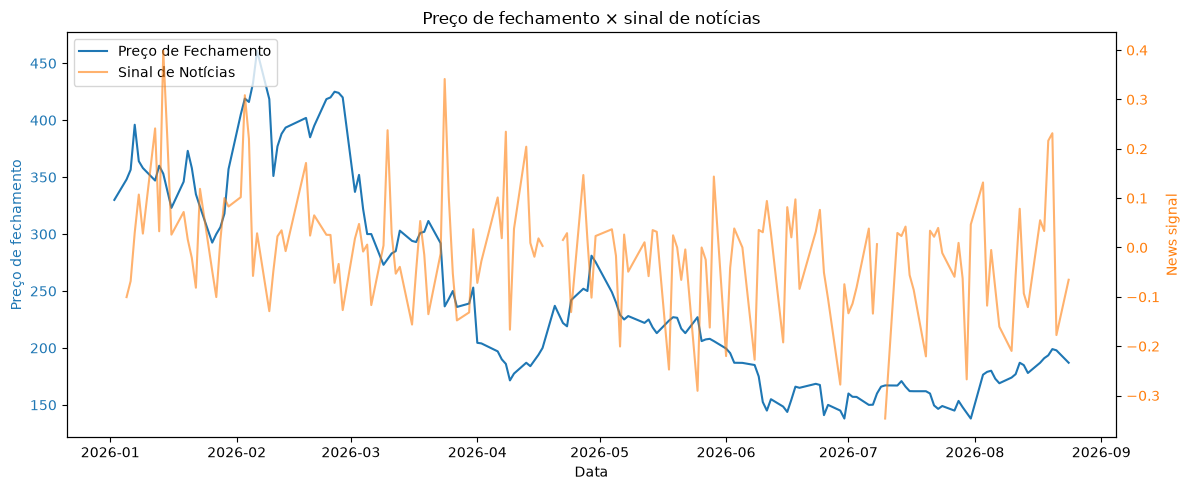

In [18]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# Define as cores e salva as referências dos plots
l1 = ax1.plot(df["date"], df["preco_fecho"], color="tab:blue", label="Preço de Fechamento")
ax1.set_xlabel("Data")
ax1.set_ylabel("Preço de fechamento", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
l2 = ax2.plot(df["date"], df["signal"], color="tab:orange", alpha=0.6, label="Sinal de Notícias")
ax2.set_ylabel("News signal", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

# Combina as linhas de ambos os eixos para criar uma legenda única
lines = l1 + l2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

ax1.set_title("Preço de fechamento × sinal de notícias")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. Signal × atividade de negociação

Notícias podem não explicar apenas direção. Elas também podem estar associadas a maior atividade ou dispersão de preços.

Vamos olhar:

- quantidade negociada;
- número de ordens;
- amplitude intraday.


In [14]:
activity_columns = [
    "signal",
    "quantidade_total",
    "total_ordens_dia",
    "intraday_range",
]

activity = df[activity_columns].dropna()

activity.corr().round(3)


,signal,quantidade_total,total_ordens_dia,intraday_range
signal,1.000,0.213,0.214,0.185
quantidade_total,0.213,1.000,0.983,0.745
total_ordens_dia,0.214,0.983,1.000,0.728
intraday_range,0.185,0.745,0.728,1.000


## 11. Correlações das principais variáveis

Esta tabela é apenas exploratória. Séries temporais possuem dependência temporal e correlação simples não deve ser interpretada como causalidade.


In [15]:
candidate_columns = [
    "preco_fecho",
    "return",
    "return_next_day",
    "intraday_range",
    "quantidade_total",
    "total_ordens_dia",
    "signal",
    "avg_score",
    "avg_relevance",
    "news_count",
    "positive_share",
    "negative_share",
    "signal_ma_3",
    "signal_ma_5",
    "signal_ma_7",
]

candidate_columns = [
    column
    for column in candidate_columns
    if column in df.columns
]

correlations = df[candidate_columns].corr()

correlations.round(3)


,preco_fecho,return,return_next_day,intraday_range,quantidade_total,total_ordens_dia,signal,avg_score,avg_relevance,news_count,positive_share,negative_share,signal_ma_3,signal_ma_5,signal_ma_7
preco_fecho,1.000,0.092,-0.094,0.562,0.455,0.459,0.240,0.162,-0.154,0.080,0.003,-0.107,0.377,0.468,0.537
return,0.092,1.000,0.007,-0.057,-0.091,-0.094,0.036,0.035,-0.001,0.011,0.071,0.031,0.031,-0.003,0.013
return_next_day,-0.094,0.007,1.000,-0.002,-0.041,-0.045,0.076,0.072,0.028,0.081,0.031,-0.012,0.046,0.026,0.014
intraday_range,0.562,-0.057,-0.002,1.000,0.729,0.713,0.185,0.124,-0.044,0.109,0.057,-0.018,0.212,0.267,0.321
quantidade_total,0.455,-0.091,-0.041,0.729,1.000,0.983,0.213,0.158,-0.040,-0.009,0.065,-0.058,0.215,0.276,0.310
total_ordens_dia,0.459,-0.094,-0.045,0.713,0.983,1.000,0.214,0.162,-0.029,0.003,0.088,-0.052,0.237,0.308,0.339
signal,0.240,0.036,0.076,0.185,0.213,0.214,1.000,0.906,-0.139,-0.024,0.427,-0.583,0.611,0.488,0.453
avg_score,0.162,0.035,0.072,0.124,0.158,0.162,0.906,1.000,-0.085,0.015,0.524,-0.637,0.508,0.388,0.376
avg_relevance,-0.154,-0.001,0.028,-0.044,-0.040,-0.029,-0.139,-0.085,1.000,0.114,0.688,0.694,0.036,0.074,0.045
news_count,0.080,0.011,0.081,0.109,-0.009,0.003,-0.024,0.015,0.114,1.000,0.074,0.104,0.011,0.014,0.021


## 12. Diagnóstico focado no próximo pregão

Ordenamos as correlações com `return_next_day` para identificar quais features merecem investigação no Notebook 03.

Não selecionaremos features para ML apenas com base nesta tabela.


In [16]:
if "return_next_day" in correlations.columns:
    next_day_correlations = (
        correlations["return_next_day"]
        .drop("return_next_day")
        .sort_values(
            key=lambda x: x.abs(),
            ascending=False,
        )
        .to_frame("correlation_with_next_return")
    )

    next_day_correlations


## 13. Persistir dataset integrado

O arquivo abaixo será a base do Notebook 03.

As variáveis de mercado e notícias permanecem explicitamente identificáveis, o que facilita experimentação sem reconstruir o merge.


In [17]:
OUTPUT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

df.to_csv(
    OUTPUT_PATH,
    index=False,
)

print(
    f"✓ Saved {len(df):,} rows to {OUTPUT_PATH}"
)


✓ Saved 159 rows to c:\Users\e702746\OneDrive - EDP\Desktop\projetos\can_ai_listen_to_the_market\data\features\energy_market_news_daily.csv
